In [7]:
import pandas as pd
import glob

# Point this to wherever you downloaded the dataset
files = glob.glob(r"E:\OneDrive\university work\assignments\sixth semester\ml project work\Group-10_Machine-Learning_Network-Intrusion-Detection\nids_unsupervised\Dataset\*.csv")  # adjust path as needed

dfs = []
for f in files:
    df = pd.read_csv(f, encoding='utf-8', low_memory=False)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df = pd.concat(dfs, ignore_index=True)

# Fix column names — strips spaces from all column names
df.columns = df.columns.str.strip()

print(df.shape)
print(df['Label'].value_counts())
print(df.shape)
print(df['Label'].value_counts())

(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                   

In [8]:
print(df.head())
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))
print(df.describe())

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [9]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())  # check they look right

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [10]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (2827876, 79)


In [11]:
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)
# 0 = Normal, 1 = Attack

print(df['binary_label'].value_counts())
print(f"Attack rate: {df['binary_label'].mean()*100:.1f}%")

binary_label
0    2271320
1     556556
Name: count, dtype: int64
Attack rate: 19.7%


In [12]:
# Take 100k rows, keeping the label balance
df_sampled = df.groupby('binary_label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50000), random_state=42)
).reset_index(drop=True)

print(df_sampled['binary_label'].value_counts())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23000\550671632.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('binary_label', group_keys=False).apply(


binary_label
0    50000
1    50000
Name: count, dtype: int64


In [13]:
# Drop the label columns — keep only numeric features
X = df_sampled.drop(columns=['Label', 'binary_label'])
y = df_sampled['binary_label']

# Keep only numeric columns (some may be object type)
X = X.select_dtypes(include=[np.number])

print(f"Features shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

Features shape: (100000, 78)
Number of features: 78


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split for supervised evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 78), Test: (20000, 78)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10000
      Attack       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC-AUC: 0.9998


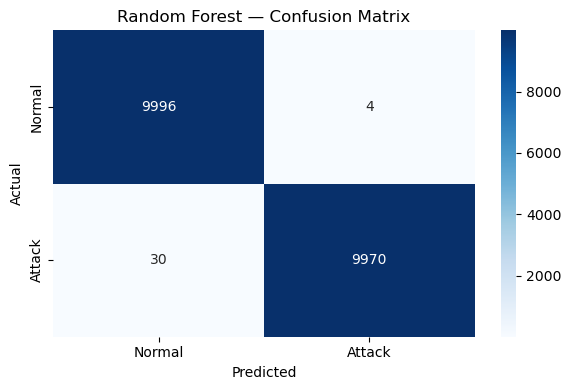

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('rf_confusion.png')
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth':    [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best F1: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Normal','Attack']))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best F1: 0.9979
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10000
      Attack       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.3,  # roughly the attack ratio in your data
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)

# Predict: IsolationForest returns -1 (anomaly) or 1 (normal)
y_pred_iso_raw = iso.predict(X_test)

# Convert to 0/1 to match our labels (1=attack, 0=normal)
y_pred_iso = (y_pred_iso_raw == -1).astype(int)

print("=== Isolation Forest Results ===")
print(classification_report(y_test, y_pred_iso, target_names=['Normal','Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_iso):.4f}")

=== Isolation Forest Results ===
              precision    recall  f1-score   support

      Normal       0.59      0.82      0.69     10000
      Attack       0.70      0.42      0.53     10000

    accuracy                           0.62     20000
   macro avg       0.65      0.62      0.61     20000
weighted avg       0.65      0.62      0.61     20000

ROC-AUC: 0.6228


In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)

# Get cluster assignments for test set
cluster_labels = kmeans.predict(X_test)

# Figure out which cluster ID corresponds to "attack"
# Do this by checking which cluster has more actual attacks
from scipy.stats import mode

cluster_to_label = {}
for cluster_id in [0, 1]:
    mask = cluster_labels == cluster_id
    actual = y_test[mask]
    # whichever class is majority in this cluster = that cluster's label
    majority = actual.mode()[0]
    cluster_to_label[cluster_id] = majority

print(f"Cluster mapping: {cluster_to_label}")

y_pred_kmeans = pd.Series(cluster_labels).map(cluster_to_label).values

print("\n=== K-Means Results ===")
print(classification_report(y_test, y_pred_kmeans, target_names=['Normal','Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_kmeans):.4f}")

Cluster mapping: {0: np.int64(1), 1: np.int64(0)}

=== K-Means Results ===
              precision    recall  f1-score   support

      Normal       0.60      0.96      0.74     10000
      Attack       0.89      0.36      0.52     10000

    accuracy                           0.66     20000
   macro avg       0.75      0.66      0.63     20000
weighted avg       0.75      0.66      0.63     20000

ROC-AUC: 0.6605


In [20]:
import joblib, os

os.makedirs(r"E:\OneDrive\university work\assignments\sixth semester\ml project work\Group-10_Machine-Learning_Network-Intrusion-Detection\Model", exist_ok=True)

model_dir = r"E:\OneDrive\university work\assignments\sixth semester\ml project work\Group-10_Machine-Learning_Network-Intrusion-Detection\Model"

joblib.dump(iso,    f"{model_dir}\\iso_model.pkl")
joblib.dump(kmeans, f"{model_dir}\\kmeans_model.pkl")
joblib.dump(scaler, f"{model_dir}\\scaler.pkl")

print("Saved: iso_model.pkl, kmeans_model.pkl, scaler.pkl")

Saved: iso_model.pkl, kmeans_model.pkl, scaler.pkl


In [21]:
import joblib
scaler = joblib.load(r"E:\OneDrive\university work\assignments\sixth semester\ml project work\Group-10_Machine-Learning_Network-Intrusion-Detection\nids_unsupervised\scaler.pkl")
print(scaler.n_features_in_)

78
